Requisitos
* Carregar os dados a partir do arquivo vendas.csv.

* Exibir informações básicas:
  * Mostrar as 5 primeiras linhas do dataset.
  * Exibir o número total de registros (linhas).
  * Calcular a receita total (coluna quantidade multiplicada pela coluna preco_unitario).
* Fazer consultas específicas:
  * Filtrar e exibir as vendas da categoria "Eletrônicos".
  * Identificar e exibir o produto mais vendido (em quantidade).
  * Descobrir e exibir a região com maior valor de compras.


Desafio extra (opcional)
* Gerar visualizações:
  * Gráfico de barras mostrando a receita por categoria.
  * Gráfico de linha mostrando a evolução das vendas por mês.
* Extra (opcional):
  * Criar um relatório exportado em .xlsx ou .pdf.
  * Montar uma tabela dinâmica com receita por região × categoria.

In [7]:
import pandas as pd

df_vendas_url = "/content/dados/vendas.csv"

df_vendas = pd.read_csv(df_vendas_url)

df_vendas.head(5)

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste


In [11]:
print(f"O número total de registros (linhas) é: {df_vendas.shape[0]}")

O número total de registros (linhas) é: 100


In [13]:
df_vendas["receita_total"] = df_vendas["quantidade"] * df_vendas["preco_unitario"]

df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,receita_total
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste,2759
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte,9032
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste,4347
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte,9138
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste,8906


In [16]:
print("\n Categoria: Eletrônicos \n")
df_vendas.loc[df_vendas["categoria"] == "Eletrônicos"]


 Categoria: Eletrônicos 



,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,receita_total
5,2025-07-24,Tablet D,Eletrônicos,2,4893,Fernanda,Sudeste,9786
6,2025-05-20,Monitor B,Eletrônicos,1,3060,Lucas,Sul,3060
9,2025-06-01,Celular A,Eletrônicos,3,516,João,Centro-Oeste,1548
10,2025-04-22,Celular A,Eletrônicos,2,1018,Fernanda,Nordeste,2036
13,2025-11-24,Notebook X,Eletrônicos,1,2670,Ana,Sul,2670
14,2025-05-30,Tablet D,Eletrônicos,4,2575,Maria,Nordeste,10300
15,2025-09-19,Notebook X,Eletrônicos,2,2778,Rafael,Norte,5556
27,2025-01-30,Notebook X,Eletrônicos,5,1006,Lucas,Sudeste,5030
32,2025-07-07,Tablet D,Eletrônicos,2,2533,Camila,Sul,5066
33,2025-11-20,Notebook X,Eletrônicos,4,3998,Pedro,Nordeste,15992


In [18]:
print("\nProduto mais vendido:")
df_vendas.groupby("produto")['quantidade'].sum().idxmax()


Produto mais vendido:


'Sofá Q'

In [23]:
print("\nRegião com maior valor total de compras:")
print(df_vendas.groupby("regiao")['receita_total'].sum().idxmax())

print("\nRegião com maior valor individual de compra:")
df_vendas.loc[df_vendas["receita_total"].idxmax(), "regiao"]


Região com maior valor total de compras:
Sudeste

Região com maior valor individual de compra:


'Centro-Oeste'

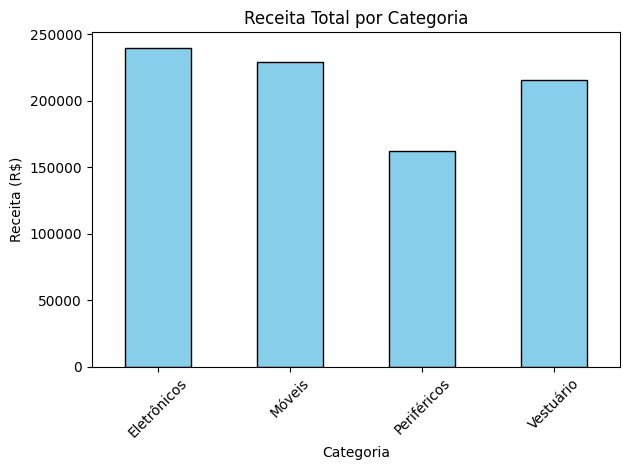

In [25]:
import matplotlib.pyplot as plt

receita_categoria = df_vendas.groupby('categoria')['receita_total'].sum()

receita_categoria.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Receita Total por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

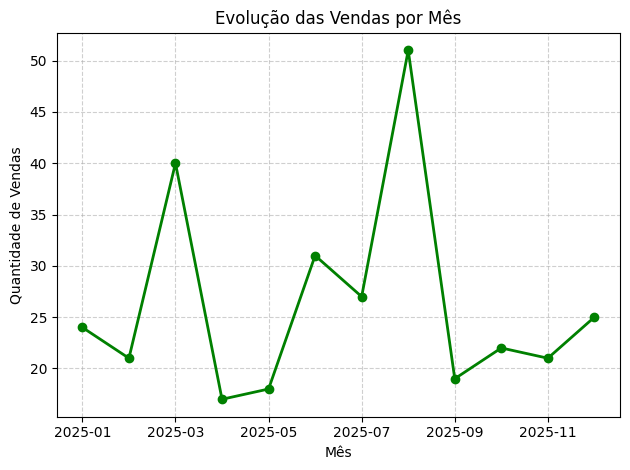

In [26]:
df_vendas['data'] = pd.to_datetime(df_vendas['data'])

df_vendas['mes'] = df_vendas['data'].dt.to_period('M')

vendas_mensais = df_vendas.groupby('mes')['quantidade'].sum()

vendas_mensais.index = vendas_mensais.index.astype(str)

vendas_mensais.plot(kind='line', marker='o', color='green', linewidth=2)

plt.title('Evolução das Vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
tabela_dinamica = df_vendas.pivot_table(
    index='regiao',
    columns='categoria',
    values='receita_total',
    aggfunc='sum',
    fill_value=0
)

print(tabela_dinamica)

categoria     Eletrônicos  Móveis  Periféricos  Vestuário
regiao                                                   
Centro-Oeste        39546   44884        25192      24106
Nordeste            51890   22870        24383      52659
Norte               38116   67464        11935      31561
Sudeste             51158   62888        69055      62504
Sul                 58679   30683        31720      44559


In [29]:
with pd.ExcelWriter('relatorio_vendas.xlsx', engine='openpyxl') as writer:
    df_vendas.to_excel(writer, sheet_name='Dados Brutos', index=False)
    tabela_dinamica.to_excel(writer, sheet_name='Resumo Regiao x Categoria')

print("Relatório Excel gerado com sucesso!")

Relatório Excel gerado com sucesso!


In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

tabela_visual = ax.table(
    cellText=tabela_dinamica.values,
    rowLabels=tabela_dinamica.index,
    colLabels=tabela_dinamica.columns,
    loc='center',
    cellLoc='center'
)

tabela_visual.auto_set_font_size(False)
tabela_visual.set_fontsize(10)
tabela_visual.scale(1.2, 1.2)

plt.savefig('relatorio_tabela_dinamica.pdf', bbox_inches='tight')
plt.close()
print("Relatório em PDF gerado com sucesso!")

Relatório em PDF gerado com sucesso!
